# Deep Neural Networks

## Assignment: A04
### Take Neural Network with :
- Multiple hidden layers 
- Activation function of your choice


Your Name and PRN:
- Name: ______________________
- PRN : ______________________
- Date: ______________________


In [1]:
###-----------------
### Import libraries
###-----------------
import numpy as np  # Import NumPy for numerical computations and array operations
import pandas as pd  # Import Pandas for data manipulation and analysis with DataFrames
import matplotlib.pyplot as plt  # Import Matplotlib for creating static, interactive visualizations
import seaborn as sns  # Import Seaborn for statistical data visualization built on Matplotlib

from sklearn.model_selection import train_test_split  # Import function to split dataset into training and testing subsets
from sklearn.metrics import (accuracy_score, 
                             classification_report, 
                             confusion_matrix, 
                             ConfusionMatrixDisplay, 
                             f1_score)  # Import function to calculate various metric



from sklearn.datasets import make_moons

from tqdm import tqdm


In [2]:
###------------------
### Global Parameters
###------------------

# Directories
#inpDir = '../../input' 
# inpDir = Path('..') / '..' / 'input'
# # outDir = '../output'
# outDir = Path('..') / 'output'


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE) # Set Random Seed for reproducible  results

TEST_SIZE  = 0.2 # Size of test data

NOISE = 0.2
N_SAMPLE = 1000
EPOCHS = 20001
ALPHA = 0.01


# Parameters for plotting
params = {'legend.fontsize': 'medium',
          'figure.figsize': (15, 6),
          'axes.labelsize': 'large',
          'axes.titlesize':'large',
          'xtick.labelsize':'medium',
          'ytick.labelsize':'medium'
         }

CMAP = plt.cm.coolwarm

plt.rcParams.update(params)

plt.style.use('seaborn-v0_8-darkgrid') # plt.style.use('ggplot')


# numpy random set
rng = np.random.default_rng(seed=RANDOM_STATE)

In [3]:
# creating dataset
X, y = make_moons(n_samples=N_SAMPLE, shuffle=True, noise=NOISE, random_state=RANDOM_STATE)

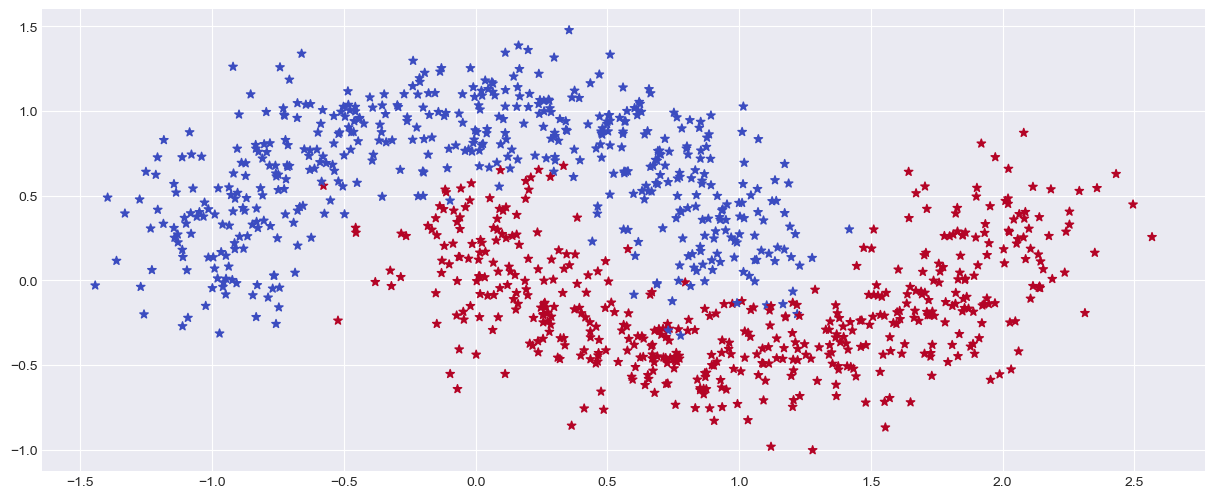

In [4]:
# plotting dataset
plt.scatter(X[:, 0], X[:, 1], s=40, c=y, marker='*', cmap=CMAP)

In [5]:
# creating a dataframe
data_df = pd.DataFrame(X, columns=['A', 'B'])
data_df['target'] = y
data_df.head()

,A,B,target
0,-0.111667,0.520224,1
1,1.142650,-0.342577,1
2,0.795558,-0.011442,1
3,0.111827,-0.551932,1
4,-0.816466,0.543996,0


In [6]:
# encoding output
y = pd.get_dummies(y).to_numpy()

In [7]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 2), (200, 2), (800, 2), (200, 2))

In [8]:
# softmax activaton function for last layer
def fn_softmax(z: np.ndarray) -> float:
     exp_score = np.exp(z - np.max(z))   # subtract to avoid overflow
     return exp_score / np.sum(exp_score, axis=1, keepdims=True)

In [9]:
# tanh activation function for hidden layers
def fn_activ(z):
    return np.tanh(z)

# tanh activation function derivative for backpropagation
def fn_activ_prime(z):
    return 1.0 - np.tanh(z)**2

In [10]:
X.shape, y.shape

((1000, 2), (1000, 2))

In [11]:
# loss calculation function
def calculate_loss(model, X_l, y_l):
    # weights and biases from model
    W1 = model['W1']
    W2 = model['W2']
    W3 = model['W3']
    W4 = model['W4']
    W5 = model['W5']
    b1 = model['b1']
    b2 = model['b2']
    b3 = model['b3']
    b4 = model['b4']
    b5 = model['b5']

    m = X_l.shape[0] # number of rows

    # first layer  ---  input enters here
    z1 = X_l.dot(W1) + b1 #aggregation
    a1 = fn_activ(z1) #activation

    # second layer
    z2 = a1.dot(W2) + b2 #aggregation
    a2 = fn_activ(z2) #activation

    # third layer
    z3 = a2.dot(W3) + b3 #aggregation
    a3 = fn_activ(z3) #activation

    # fourth layer
    z4 = a3.dot(W4) + b4 #aggregation
    a4 = fn_activ(z4) #activation

    # fifth layer  --- output layer
    z5 = a4.dot(W5) + b5 #aggregation
    a5 = fn_softmax(z5) #activation

    
    data_loss = -(y_l * np.log(a5) + (1-y_l) * np.log(1-a5)).sum()
    return data_loss/m

In [12]:
# predict function - forward propagation
def predict(model, X_p):
    W1 = model['W1']
    W2 = model['W2']
    W3 = model['W3']
    W4 = model['W4']
    W5 = model['W5']
    b1 = model['b1']
    b2 = model['b2']
    b3 = model['b3']
    b4 = model['b4']
    b5 = model['b5']

    # first layer  ---  input enters here
    z1 = X_p.dot(W1) + b1 #aggregation
    a1 = fn_activ(z1) #activation

    # second layer
    z2 = a1.dot(W2) + b2 #aggregation
    a2 = fn_activ(z2) #activation

    # third layer
    z3 = a2.dot(W3) + b3 #aggregation
    a3 = fn_activ(z3) #activation

    # fourth layer
    z4 = a3.dot(W4) + b4 #aggregation
    a4 = fn_activ(z4) #activation

    # fifth layer  --- output layer
    z5 = a4.dot(W5) + b5 #aggregation
    a5 = fn_softmax(z5) #activation


    return a5.argmax(axis=1)  # return prediction based on highest probability


In [13]:
# function to build model
def build_model(param, train_x, train_y, test_x, test_y, alpha, n_epoch, hist):
    m = train_x.shape[0] # number of rows
    
    # weights initialization
    W1 = rng.random((param['h_dim'][0], param['h_dim'][1])) / np.sqrt(param['h_dim'][0])
    W2 = rng.random((param['h_dim'][1], param['h_dim'][2])) / np.sqrt(param['h_dim'][1])
    W3 = rng.random((param['h_dim'][2], param['h_dim'][3])) / np.sqrt(param['h_dim'][2])
    W4 = rng.random((param['h_dim'][3], param['h_dim'][4])) / np.sqrt(param['h_dim'][3])
    W5 = rng.random((param['h_dim'][4], param['h_dim'][5])) / np.sqrt(param['h_dim'][4])

    # biases initialization
    b1 = np.zeros((1,param['h_dim'][1]))
    b2 = np.zeros((1,param['h_dim'][2]))
    b3 = np.zeros((1,param['h_dim'][3]))
    b4 = np.zeros((1,param['h_dim'][4]))
    b5 = np.zeros((1,param['h_dim'][5]))

    loss, epoch, test_loss = [], [], [] # to store losses and epochs
    train_accuracy, test_accuracy = [], [] # to store accuracy

    for i in range(n_epoch): # loop over epochs

# -----------> FORWARD PROPAGATION< -----------
        # first layer  ---  input enters here
        z1 = train_x.dot(W1) + b1 #aggregation
        a1 = fn_activ(z1) #activation

        # second layer
        z2 = a1.dot(W2) + b2 #aggregation
        a2 = fn_activ(z2) #activation

        # third layer
        z3 = a2.dot(W3) + b3 #aggregation
        a3 = fn_activ(z3) #activation

        # fourth layer
        z4 = a3.dot(W4) + b4 #aggregation
        a4 = fn_activ(z4) #activation

        # fifth layer  --- output layer
        z5 = a4.dot(W5) + b5 #aggregation
        a5 = fn_softmax(z5) #activation

 # -----------> BACKWARD PROPAGATION of loss< -----------
        # Layer 5
        dz5 = a5 - train_y 
        assert(z5.shape == dz5.shape), f'Shape z5: {z5.shape},{dz5.shape}'        

        dW5 = a4.T.dot(dz5)
        assert(W5.shape == dW5.shape), f'Shape W5: {W5.shape},{dW5.shape}'

        db5 = np.sum(dz5, axis=0, keepdims=True)
        assert(b5.shape == db5.shape), f'Shape b5: {b5.shape},{db5.shape}'
        
        da4 = dz5.dot(W5.T)
        assert(a4.shape == da4.shape),  f'Shape a4: {a4.shape},{da4.shape}'

        # LAYER 4
        dz4 = da4 * fn_activ_prime(z4)
        assert(z4.shape == dz4.shape), f'Shape z4: {z4.shape},{dz4.shape}'        

        dW4 = a3.T.dot(dz4)
        assert(W4.shape == dW4.shape), f'Shape W4: {W4.shape},{dW4.shape}'

        db4 = np.sum(dz4, axis=0, keepdims=True)
        assert(b4.shape == db4.shape), f'Shape b4: {b4.shape},{db4.shape}'
        
        da3 = dz4.dot(W4.T)
        assert(a3.shape == da3.shape),  f'Shape a3: {a3.shape},{da3.shape}'

        # LAYER 3
        dz3 = da3 * fn_activ_prime(z3)
        assert(z3.shape == dz3.shape), f'Shape z3: {z3.shape},{dz3.shape}'        

        dW3 = a2.T.dot(dz3)
        assert(W3.shape == dW3.shape), f'Shape W3: {W3.shape},{dW3.shape}'

        db3 = np.sum(dz3, axis=0, keepdims=True)
        assert(b3.shape == db3.shape), f'Shape b3: {b3.shape},{db3.shape}'
        
        da2 = dz3.dot(W3.T)
        assert(a2.shape == da2.shape),  f'Shape a2: {a2.shape},{da2.shape}'

        # LAYER 2
        dz2 = da2 * fn_activ_prime(z2)
        assert(z2.shape == dz2.shape), f'Shape z2: {z2.shape},{dz2.shape}'        

        dW2 = a1.T.dot(dz2)
        assert(W2.shape == dW2.shape), f'Shape W2: {W2.shape},{dW2.shape}'

        db2 = np.sum(dz2, axis=0, keepdims=True)
        assert(b2.shape == db2.shape), f'Shape b2: {b2.shape},{db2.shape}'
        
        da1 = dz2.dot(W2.T)
        assert(a1.shape == da1.shape),  f'Shape a1: {a1.shape},{da1.shape}'

        # LAYER 1
        dz1 = da1 * fn_activ_prime(z1)
        assert(z1.shape == dz1.shape),  f'Shape b2: {z1.shape},{dz1.shape}'

        dW1 = (train_x.T).dot(dz1)
        assert(W1.shape == dW1.shape), f'Shape b2: {W1.shape},{dW1.shape}'

        db1 = np.sum(dz1, axis=0, keepdims=True)
        assert(b1.shape == db1.shape), f'Shape b2: {b1.shape},{db1.shape}'


        # updating weights and biases
        W1 = W1 - alpha * dW1 / m
        b1 = b1 - alpha * db1 / m
        W2 = W2 - alpha * dW2 / m
        b2 = b2 - alpha * db2 / m
        W3 = W3 - alpha * dW3 / m
        b3 = b3 - alpha * db3 / m
        W4 = W4 - alpha * dW4 / m
        b4 = b4 - alpha * db4 / m
        W5 = W5 - alpha * dW5 / m
        b5 = b5 - alpha * db5 / m

        # storing model parameters in dictionary
        model = {'W1':W1, 'W2':W2, 'W3':W3,  'W4':W4, 'W5':W5, 
                'b1':b1,  'b2':b2, 'b3':b3, 'b4':b4, 'b5':b5}

        # calculating losses and accuracy
        current_loss = calculate_loss(model, train_x, train_y)
        current_test_loss = calculate_loss(model, test_x, test_y)
        y_pred = predict(model, train_x)
        y_pred_test = predict(model, test_x)
        

        # storing 
        epoch.append(i)
        loss.append(current_loss)
        test_loss.append(current_test_loss)
        train_accuracy.append(accuracy_score(train_y.argmax(axis=1), y_pred))
        test_accuracy.append(accuracy_score(test_y.argmax(axis=1), y_pred_test))

        
    hist['epoch'] = epoch
    hist['train_loss'] = loss
    hist['test_loss'] = test_loss
    hist['train_accuracy'] = train_accuracy
    hist['test_accuracy'] = test_accuracy


    return model


With scaling

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scl = scaler.fit_transform(X_train)
X_test_scl = scaler.transform(X_test)

In [15]:
def fn_plot_decision_boundary(X: np.ndarray, y: np.ndarray, model:dict, predict):
    
    # Initialize the figure with specified dimensions
    fig, ax = plt.subplots( figsize=(8, 5) )
    
    # Small increment value to create a fine grid for smooth decision boundary
    dm = 0.01
    padding = 2 * dm
    
    # Calculate the range for x-axis (first feature) with padding
    x_min, x_max = X[:, 0].min() - padding, X[:, 0].max() + padding
    
    # Calculate the range for y-axis (second feature) with padding  
    y_min, y_max = X[:, 1].min() - padding, X[:, 1].max() + padding
    
    # Create a mesh grid covering the entire feature space
    xx, yy = np.meshgrid(np.arange(x_min, x_max, dm),
                         np.arange(y_min, y_max, dm))
    
    # Flatten the mesh grid arrays and stack them column-wise to create coordinate pairs
    XX = np.c_[xx.ravel(), yy.ravel()] # Resulting shape: (n_points, 2)

    # List to collect predictions for each point in the mesh grid
    y_pred = predict(model,XX)
        
    # Reshape predictions to match the original mesh grid dimensions
    Z = np.array(y_pred).reshape(xx.shape)

    # Create filled contour plot showing the decision regions
    ax.contourf(xx, yy, Z, alpha=0.6, cmap=plt.cm.Paired)
    
    # Scatter plot of the actual data points, colored by their true class labels
    ax.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k', cmap=plt.cm.bwr)
    
    # Set plot title and axis labels
    ax.set_title('Decision Boundary')
    ax.set_xlabel('A')  
    ax.set_ylabel('B') 
    
    # Display the final plot
    plt.show()

In [16]:
# function for model training

def multiple_layer_perceptron(param_grid, learning_rate, epochs):

    hist = {} # dictionary to store model history

    # calling build_model function for training
    model = build_model(param=param_grid, train_x=X_train_scl, train_y=y_train, test_x=X_test_scl,
                    test_y=y_test, alpha=learning_rate, n_epoch=epochs, hist=hist)

    hist_df = pd.DataFrame(hist)   # storing data into dataframe

    # plotting for loss and accuracy curve
    fig, axes = plt.subplots(1, 2, figsize=(10, 6))

    final_train_loss = hist_df['train_loss'].iloc[-1]
    final_test_loss = hist_df['test_loss'].iloc[-1]
    axes[0].plot(hist_df['train_loss'], label='train_loss', lw=2)
    axes[0].plot(hist_df['test_loss'], label='test_loss', lw=2)
    axes[0].legend()
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'Loss: train = {final_train_loss:.4f}, test = {final_test_loss:.4f}')


    final_train_accuracy = hist_df['train_accuracy'].iloc[-1]
    final_test_accuracy = hist_df['test_accuracy'].iloc[-1]
    axes[1].plot(hist_df['train_accuracy'], label='train_accuracy', lw=2)
    axes[1].plot(hist_df['test_accuracy'], label='test_accuracy', lw=2)
    axes[1].legend()
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'Accuracy: train = {final_train_accuracy:.3f}, test = {final_test_accuracy:.3f}')
    plt.tight_layout()
    plt.show()


    # plotting decision boundary for X_train
    fn_plot_decision_boundary(X_train_scl, y_train.argmax(axis=1), model, predict)

    # Evaluation on training set
    y_pred = predict(model, X_train_scl)
    print('Classification report -- Train Set')
    print(classification_report(y_train.argmax(axis=1), y_pred))
    f1 = f1_score(y_train.argmax(axis=1), y_pred, average='weighted')
    cm_train = confusion_matrix(y_train.argmax(axis=1), y_pred)
    disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=['A', 'B'])

    # Evaluation on testing set
    y_pred = predict(model, X_test_scl)
    print('Classification report -- Test Set')
    print(classification_report(y_test.argmax(axis=1), y_pred))
    f1 = f1_score(y_test.argmax(axis=1), y_pred, average='weighted')
    cm_test = confusion_matrix(y_test.argmax(axis=1), y_pred)
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['A', 'B'])

    # plotting confusion matrices for model's prediction on train and test set
    fig, axes = plt.subplots(1, 2, figsize=(6, 4))

    ax = axes[0]
    disp_train.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.grid(False)
    ax.set_title(f'Train set - Confusion Matrix')
    plt.tight_layout()

    ax = axes[1]
    disp_test.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.grid(False)
    ax.set_title(f'Test set - Confusion Matrix')
    plt.tight_layout()
    plt.show()
    

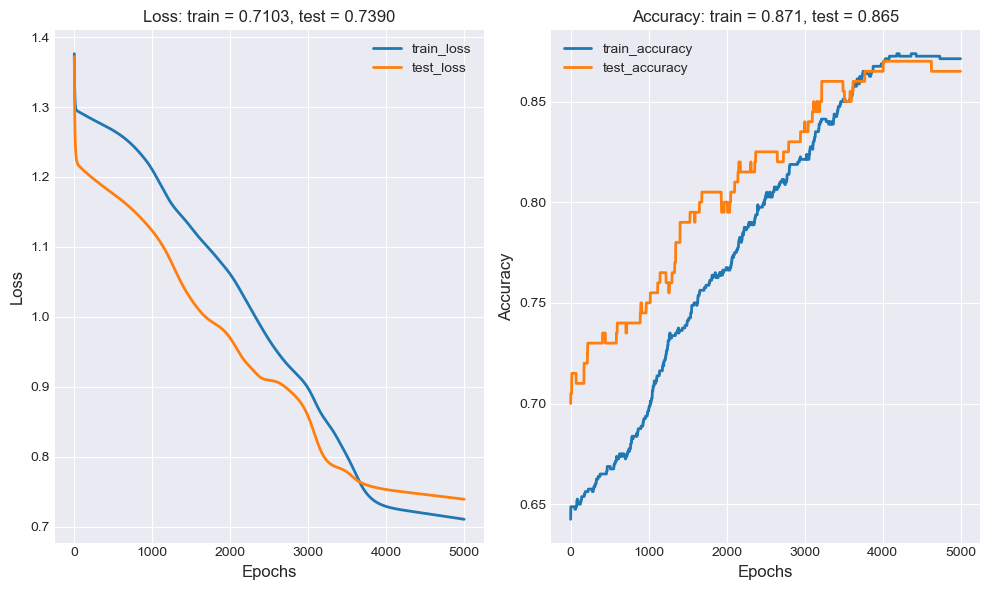

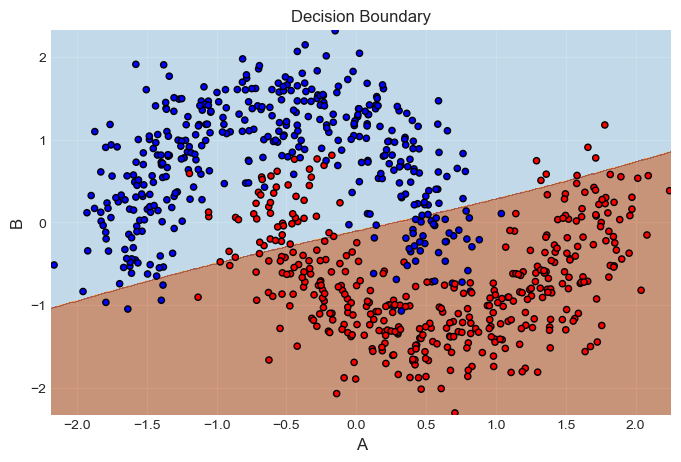

Classification report -- Train Set
              precision    recall  f1-score   support

           0       0.86      0.89      0.87       400
           1       0.88      0.86      0.87       400

    accuracy                           0.87       800
   macro avg       0.87      0.87      0.87       800
weighted avg       0.87      0.87      0.87       800

Classification report -- Test Set
              precision    recall  f1-score   support

           0       0.85      0.88      0.87       100
           1       0.88      0.85      0.86       100

    accuracy                           0.86       200
   macro avg       0.87      0.86      0.86       200
weighted avg       0.87      0.86      0.86       200



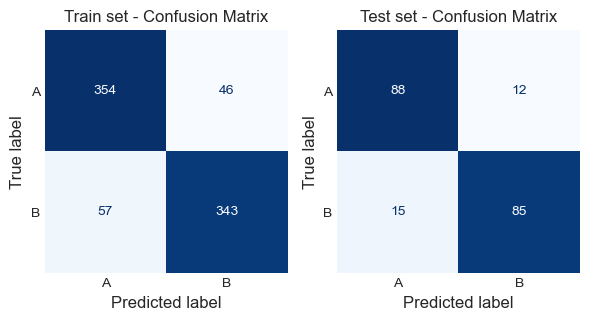

In [25]:
param = {}
param['h_dim'] = [X_train.shape[1], 50, 40, 30, 20, y_train.shape[1]] 

multiple_layer_perceptron(param, learning_rate=0.01, epochs=5000)


### Assignment
- **Q1**: Is this model more accurate compared to previous model?<br>
Ans: Yes, this model is more accurate compared to previous model which had a single layer. But this depends on the factors like learning rate, number of nodes, epochs etc. because the model is not always better than the previous one. If we compare the best single layer model that we were able to find and this multilayer model, the overall best one is the multilayer one with the right combination of parameters. <br>

- **Q2**: Prepare table by changing number of neurons in hidden layer, learning rate and observe change in results. Also comment on your results. <br>
Ans: 
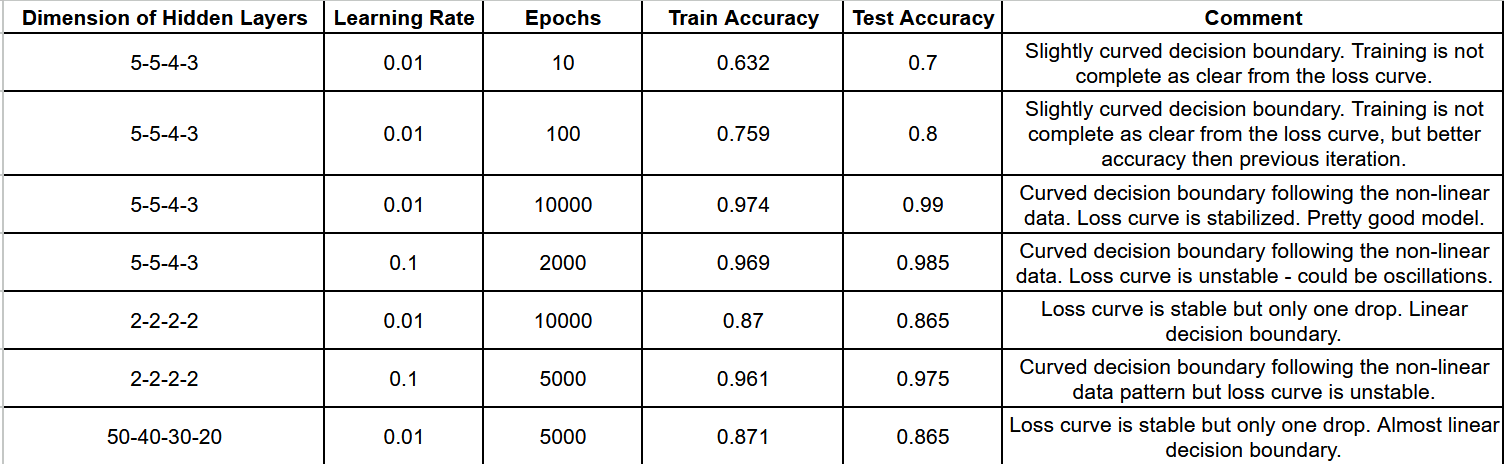

<br>
We see that the performance of the model depends upon learning rate, epochs and number of nodes. If we decrease the number of epochs, the loss curve does not stabilize. If we decrease the number of nodes, we need to increase the number of nodes to reach the minimum loss as seen in other cases. If we increase the learning rate, the loss curve becomes unstable suggesting us that for this data, a low learning rate will be able to reach the optimal solution.